# Third-moment comparison: linear δ-synapse Hawkes

Two theory files describing the same physical process:

* `single_population_linear_delta_voltage_test` — voltage model with δ-synapse (`g(t)=δ(t)`); v has time dynamics.
* `single_population_linear_delta_spikes_test` — spikes-side formulation after integrating v out; v is algebraic (slave), and the membrane filter `g_i(t)=(1/τ_i)·e^(-t/τ_i)·θ(t)` now lives in `Conv(g_i, n_j)` on the vt-equation.

They MUST give identical n-correlators at every order. The third moment ⟨n n n⟩ is the target — the spikes-side theory exercises a non-trivial convolutional vertex that the voltage theory does not.

## 1. Setup

In [1]:
%display latex
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, sys, time, importlib.util
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from pipeline import compute_cumulants
from models.hawkes_sim_multipop_numba import (
    sim_hawkes_multipop_linear_softreset_delta_numba,
    flat_index_of,
)
from models.cumulant_estimator import compute_kpoint_slice

## 2. Configuration — shared between both theories

In [2]:
# Theory parameters (identical for both theories).
fundamental = {
    'Em':  [0.8, 0.78],
    'tau': [10.0, 9.0],
    'w':   [[0.0, 0.25], [0.2, 0.0]],
}

k       = 3
max_ell = 0    # tree-level only

# Pick MIXED-population external legs at non-coincident lags so the
# sim-side estimator gives the smooth (off-diagonal) cumulant without
# shot-noise δ-spike contamination at the sweep midpoint.
external_fields = [('n', 1), ('n', 1), ('n', 2)]
TAU_FIXED = 1.0   # leg-3 pinned at +1.0; leg-2 sweeps; leg-1 pinned at 0.

tau_max  = 8.0
tau_step = 0.5

# Simulation knobs.
N_RUNS = 4
T_sim  = 20_000_000.0    # k=3 needs more data than k=2 (variance scales worse)
dt_sim = 0.01
dt_bin = 0.25

print(f'k={k}, max_ell={max_ell}, external_fields={external_fields}')
print(f'TAU_FIXED={TAU_FIXED}, tau_max={tau_max}, tau_step={tau_step}')
print(f'N_RUNS={N_RUNS}, T_sim={T_sim:.0g}, dt_sim={dt_sim}, dt_bin={dt_bin}')

k=3, max_ell=0, external_fields=[('n', 1), ('n', 1), ('n', 2)]
TAU_FIXED=1.00000000000000, tau_max=8.00000000000000, tau_step=0.500000000000000
N_RUNS=4, T_sim=2e+7, dt_sim=0.0100000000000000, dt_bin=0.250000000000000


## 3. Theory side — both files

In [3]:
# Helper: load a theory file by THEORY_NAME (filename minus .theory.py).
def _load_theory(theory_name):
    path = os.path.abspath(f'../theories/{theory_name}.theory.py')
    spec = importlib.util.spec_from_file_location(theory_name, path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.build()

model_voltage = _load_theory(
    'single_population_linear_delta_voltage_test')
model_spikes  = _load_theory(
    'single_population_linear_delta_spikes_test')

print(f"voltage model: {model_voltage['name']}")
print(f"spikes  model: {model_spikes['name']}")

voltage model: Single population Linear Delta Voltage Test
spikes  model: Single population Linear Delta Spikes Test


In [4]:
# Run compute_cumulants for each theory. With use_cache=False to
# guarantee a fresh build (until we've added content-fingerprinting
# to the cache invalidation logic).
def _run(model, label):
    t0 = time.perf_counter()
    th = compute_cumulants(
        model               = model,
        k                   = k,
        max_ell             = max_ell,
        fundamental         = fundamental,
        external_fields     = external_fields,
        tau_max             = tau_max,
        tau_step            = tau_step,
        parallel            = False,
        use_cache           = False,
        verbose             = False,
    )
    print(f'  {label}: {time.perf_counter()-t0:.1f}s '
          f'(nstar={th["mf_values"]["nstar"]}, '
          f'{sum(1 for d in th["diagrams"] if d["ell"]==0)} tree diagrams)')
    return th

print('Computing tree-level k=3 cumulants:')
th_voltage = _run(model_voltage, 'voltage')
th_spikes  = _run(model_spikes,  'spikes')

Computing tree-level k=3 cumulants:


=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM


  voltage: 4.0s (nstar=[1.0473684210526317, 0.9894736842105264], 10 tree diagrams)


=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM


  spikes: 8.3s (nstar=[1.0473684210526317, 0.9894736842105264], 10 tree diagrams)


## 4. Verify the two theories agree (must be identical to machine precision)

In [5]:
# Evaluate total_C on a τ-grid for the sweep axis (leg 2).
# Convention: total_C(τ_1, τ_2, τ_3) where τ_1=0 by pipeline default.
tau_grid_th = np.arange(-tau_max, tau_max + 1e-9, tau_step)
C_voltage = np.array([
    complex(th_voltage["total_C"](0.0, float(t), float(TAU_FIXED))).real
    for t in tau_grid_th
])
C_spikes  = np.array([
    complex(th_spikes["total_C"](0.0, float(t), float(TAU_FIXED))).real
    for t in tau_grid_th
])

diff = C_voltage - C_spikes
print(f'max |voltage − spikes|: {np.abs(diff).max():.3e}')
print(f'max C_voltage:           {np.abs(C_voltage).max():.3e}')
print(f'relative match:          {np.abs(diff).max() / np.abs(C_voltage).max():.3e}')

print()
print(f'{"τ":>6}  {"voltage":>14}  {"spikes":>14}  {"diff":>10}')
for t, vv, vs in zip(tau_grid_th, C_voltage, C_spikes):
    if t % 2 < tau_step/2 or abs(t) < tau_step/2:
        print(f'{t:+6.1f}  {vv:+.7e}  {vs:+.7e}  {(vv-vs):+.2e}')

max |voltage − spikes|: 0.000e+00
max C_voltage:           5.915e-04
relative match:          0.000e+00

     τ         voltage          spikes        diff
  -8.0  +1.0927224e-04  +1.0927224e-04  +0.00e+00
  -6.0  +1.2174053e-04  +1.2174053e-04  +0.00e+00
  -4.0  +1.3298756e-04  +1.3298756e-04  +0.00e+00
  -2.0  +1.4056166e-04  +1.4056166e-04  +0.00e+00
  +0.0  +1.3995942e-04  +1.3995942e-04  +0.00e+00
  +2.0  +5.6776144e-04  +5.6776144e-04  +0.00e+00
  +4.0  +4.8213245e-04  +4.8213245e-04  +0.00e+00
  +6.0  +4.0944806e-04  +4.0944806e-04  +0.00e+00
  +8.0  +3.4774455e-04  +3.4774455e-04  +0.00e+00


## 5. Simulation — single linear-rate δ-synapse Hawkes (no reset)

In [6]:
import secrets as _secrets

# Build sim arrays from fundamental / mf saddle.
pops = model_voltage['populations']
pop_offsets = {p['name']: (sum(int(q['size']) for q in pops[:i]),
                            int(p['size']))
               for i, p in enumerate(pops)}
N = sum(int(p['size']) for p in pops)

tau_v   = np.array([float(t) for t in fundamental['tau']])
a_gain  = np.ones(N)                       # linear φ(v)=v
E_drive = np.array([float(e) for e in fundamental['Em']])
w_in    = fundamental['w']
W       = np.array([[float(w_in[i][j]) for j in range(N)] for i in range(N)])
tau_g_arr = np.ones((N, N))                # ignored by the delta sim
mf = th_voltage['mf_values']
v_init = np.array(mf['nstar'], dtype=float)  # nstar == vstar for linear φ

print(f'N = {N}')
print(f'tau_v   = {tau_v}')
print(f'E_drive = {E_drive}')
print(f'v_init  = {v_init}   (MF saddle)')

N = 2
tau_v   = [10.  9.]
E_drive = [0.8  0.78]
v_init  = [1.04736842 0.98947368]   (MF saddle)


In [7]:
# Discretization
n_steps        = int(T_sim / dt_sim)
bin_size_steps = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff     = bin_size_steps * dt_sim
n_bins         = int(n_steps // bin_size_steps)
max_lag_bins   = int(round(tau_max / dt_bin_eff))
fixed_lag_bins = int(round(float(TAU_FIXED) / float(dt_bin_eff)))

# Per-leg pop index for compute_kpoint_slice.
pop_indices = [flat_index_of(model_voltage, pop_offsets, ef[0], ef[1])
               for ef in external_fields]
field_types = [ef[0] for ef in external_fields]
print(f'External fields {external_fields} → flat sim indices {pop_indices}')

# JIT warmup
_ = sim_hawkes_multipop_linear_softreset_delta_numba(
    int(1000), float(dt_sim), tau_v, a_gain, E_drive, W, tau_g_arr,
    v_init.copy(), int(bin_size_steps), int(100), int(0), float(0.0),
)
print('JIT warmup done.')

External fields [('n', 1), ('n', 1), ('n', 2)] → flat sim indices [0, 0, 1]


JIT warmup done.


In [8]:
BASE_SEED = _secrets.randbits(31)
C_sim_runs   = []
rate_runs    = []

lag_bins_sim = [0, None, fixed_lag_bins]   # leg 0 @0, leg 1 sweep, leg 2 @+TAU_FIXED

t0 = time.perf_counter()
for run in range(N_RUNS):
    seed = int(BASE_SEED + run)
    binned_counts, voltage_bins, total_spikes = (
        sim_hawkes_multipop_linear_softreset_delta_numba(
            int(n_steps), float(dt_sim),
            tau_v, a_gain, E_drive, W, tau_g_arr,
            v_init.copy(),
            int(bin_size_steps), int(n_bins), int(seed), float(0.0),
        )
    )
    rate_runs.append(total_spikes / T_sim)
    tau_grid_sim, C_run = compute_kpoint_slice(
        binned_counts, float(dt_bin_eff),
        [int(p) for p in pop_indices],
        lag_bins_sim, int(max_lag_bins),
        field_types=field_types,
    )
    C_sim_runs.append(C_run)
    print(f'  run {run+1}/{N_RUNS}: rates={rate_runs[-1]}, '
          f'total {time.perf_counter()-t0:.0f}s')

C_sim_runs   = np.array(C_sim_runs)
C_sim_mean   = C_sim_runs.mean(axis=0)
C_sim_sem    = C_sim_runs.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
rate_sim     = np.array(rate_runs).mean(axis=0)
rate_sim_sem = np.array(rate_runs).std(axis=0, ddof=1) / np.sqrt(N_RUNS)

print(f'\nSimulation total: {time.perf_counter()-t0:.0f}s '
      f'({N_RUNS} runs × T={T_sim:.0g})')
print(f'  sim rates: {rate_sim}  (SEM {rate_sim_sem})')
print(f'  MF nstar:  {mf["nstar"]}')

  run 1/4: rates=[1.04732445 0.98947975], total 87s


  run 2/4: rates=[1.0472511  0.98933235], total 174s


  run 3/4: rates=[1.04784365 0.98971165], total 261s


  run 4/4: rates=[1.04729175 0.9893363 ], total 348s

Simulation total: 348s (4 runs × T=2e+7)
  sim rates: [1.04742774 0.98946501]  (SEM [1.39446800e-04 8.90755751e-05])
  MF nstar:  [1.0473684210526317, 0.9894736842105264]


## 6. Three-way comparison plot

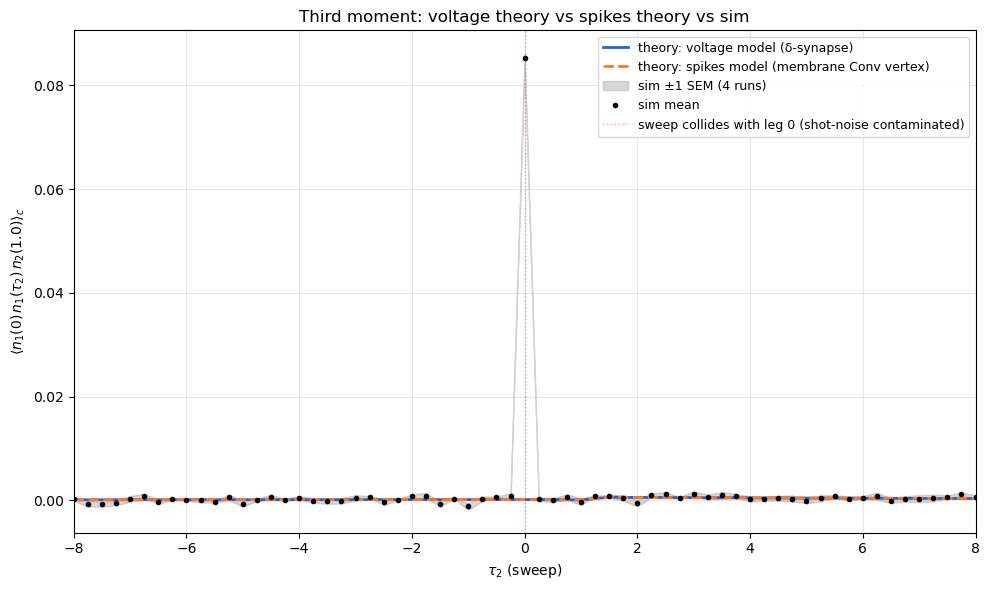

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# Theory curves on the tau_grid_th (analytic τ-step).
ax.plot(tau_grid_th, C_voltage, '-',  color='#2266CC', lw=2,
        label='theory: voltage model (δ-synapse)')
ax.plot(tau_grid_th, C_spikes,  '--', color='#FF7733', lw=2,
        label='theory: spikes model (membrane Conv vertex)')

# Sim with shaded SEM band, on the sim τ-grid (dt_bin_eff resolution).
ax.fill_between(tau_grid_sim,
                C_sim_mean - C_sim_sem,
                C_sim_mean + C_sim_sem,
                color='gray', alpha=0.3, label=f'sim ±1 SEM ({N_RUNS} runs)')
ax.plot(tau_grid_sim, C_sim_mean, 'o', color='black', ms=3, label='sim mean')

# Mark shot-noise contamination at sweep = 0 (where leg 1 coincides with leg 0).
# Both fixed-leg populations are pop-0; the sweep leg pop is also pop-0,
# so sweep_lag=0 collides with leg-0's lag.
if pop_indices[0] == pop_indices[1]:
    ax.axvline(0.0, color='red', alpha=0.4, ls=':', lw=1,
               label='sweep collides with leg 0 (shot-noise contaminated)')
if pop_indices[1] == pop_indices[2]:
    ax.axvline(TAU_FIXED, color='magenta', alpha=0.4, ls=':', lw=1,
               label=f'sweep collides with leg 2 ({TAU_FIXED:.1f})')

ax.set_xlabel(r'$\tau_2$ (sweep)')
ax.set_ylabel(
    fr'$\langle n_{{{pop_indices[0]+1}}}(0)\, n_{{{pop_indices[1]+1}}}(\tau_2)\, '
    fr'n_{{{pop_indices[2]+1}}}({TAU_FIXED:.1f})\rangle_c$'
)
ax.set_title('Third moment: voltage theory vs spikes theory vs sim')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-tau_max, tau_max)
plt.tight_layout()
plt.show()

## 7. Numerical residual table

In [10]:
# Interpolate theory onto the sim τ-grid for a same-grid residual.
C_voltage_on_sim = np.interp(tau_grid_sim, tau_grid_th, C_voltage)
C_spikes_on_sim  = np.interp(tau_grid_sim, tau_grid_th, C_spikes)

# Mask shot-noise-contaminated lags.
mask = np.ones_like(tau_grid_sim, dtype=bool)
if pop_indices[0] == pop_indices[1]:
    mask &= np.abs(tau_grid_sim) > dt_bin_eff/2
if pop_indices[1] == pop_indices[2]:
    mask &= np.abs(tau_grid_sim - TAU_FIXED) > dt_bin_eff/2

resid_voltage = C_sim_mean - C_voltage_on_sim
resid_spikes  = C_sim_mean - C_spikes_on_sim

print(f'Residual stats on un-contaminated sweep bins ({mask.sum()} of '
      f'{len(tau_grid_sim)}):')
print(f'  RMS sim − theory(voltage): {np.sqrt(np.mean(resid_voltage[mask]**2)):.3e}')
print(f'  RMS sim − theory(spikes):  {np.sqrt(np.mean(resid_spikes[mask]**2)):.3e}')
print(f'  Median SEM:                {np.median(C_sim_sem[mask]):.3e}')
print(f'  RMS theory:                {np.sqrt(np.mean(C_voltage_on_sim[mask]**2)):.3e}')

Residual stats on un-contaminated sweep bins (64 of 65):
  RMS sim − theory(voltage): 4.735e-04
  RMS sim − theory(spikes):  4.735e-04
  Median SEM:                4.371e-04
  RMS theory:                3.201e-04
